### General License: Limiting use of code

-- General License --

MIT License

Copyright (c) [2025] [Nikhil Arora]

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

### Use drop-down arrows on the left of each header/sub-header to expand to the steps/code.

## Deep Learning Classifier Tuning

### Task: Building and Fine-tuning Classifier

#### Importing libraries and data

In [46]:
## Loading Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, recall_score, precision_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [15]:
## Loading Dataset
cars_df = pd.read_csv("cars.csv")

#### Data Preprocessing

In [16]:
cars_df.shape
cars_df.dtypes

Buy             object
Maint_costs     object
Doors           object
Person         float64
Boot            object
Safety          object
Quality         object
dtype: object

In [17]:
# Checking for duplicates (additional step)
cars_df.duplicated().any()
# Returns true, so need to remove them

# Removing duplicates
cars_df = cars_df.drop_duplicates()
cars_df.shape
#Dropped 73 records

# Rechecking for duplicates
cars_df.duplicated().any()

False

In [18]:
# Checking for missing values
cars_df.isna().sum()

Buy             15
Maint_costs     41
Doors            0
Person         554
Boot            42
Safety           0
Quality          0
dtype: int64

-   - For "Person" column there are 554 attributes with missing values, which is about 33% of the total records. 
        Imputing so much values can create a bias in the data. So, it is better to remove the whole column from the analysis.
    - For "Buy", "Main_cost" and "Boot" columns it is better to remove the corresponding records with empty values, as such imputing categoricals can result in misrepresentation, resulting in bad predictions.

In [19]:
cars_df = cars_df.drop("Person", axis = 1)
cars_df.shape

cars_df = cars_df.dropna()
cars_df.shape
#Dropped 97 more records

# Rechecking for missing values
cars_df.isna().sum()

Buy            0
Maint_costs    0
Doors          0
Boot           0
Safety         0
Quality        0
dtype: int64

In [20]:
#Transforming the categoricals
#As Quality column is of interest and class label, transforming it manually
cars_df['Quality'] = cars_df['Quality'].replace({
    'unacc': 0,
    'acc': 1,
    'good': 2,
    'vgood': 3})
cars_df.dtypes
#For rest of the columns
for col in cars_df.columns:
    if cars_df[col].dtype == "object":
        cars_df[col] = cars_df[col].astype("category").cat.codes
cars_df.dtypes

# If required: Export Preprocessed Data
# cars_df.to_csv('processed_cars.csv', index = False)

C:\Users\nikhi\AppData\Local\Temp\ipykernel_33552\3486406911.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_df['Quality'] = cars_df['Quality'].replace({


Buy             int8
Maint_costs     int8
Doors           int8
Boot            int8
Safety          int8
Quality        int64
dtype: object

#### Model 1: Defining Initial Model

In [23]:
#Defining target(class label) and input variables
features = cars_df.drop("Quality", axis=1)
classLabels = cars_df["Quality"]

#Splitting the data into training and testing sets in ratio 75% to 25%
X_train, X_test, y_train, y_test = train_test_split(features, classLabels,
                                                    random_state=1)

#Defining Cost Matrix
CM = np.array([[0, 1, 8 ,10],
               [1, 0, 4, 6],
               [3, 1, 0, 1],
               [6, 2, 1, 0]])

In [28]:
# Model 1 #

# With 1 layer of 120 neurons, optimizer 'sgd', iterations=200, lr = 0.0001
m1 = MLPClassifier(hidden_layer_sizes = (120),
                   max_iter=200,
                   learning_rate_init=0.001,
                   solver='sgd',
                   random_state=1)

m1.fit(X_train, y_train)

C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=120, random_state=1, solver='sgd')

In [29]:
#Primary Evaluation
pred = m1.predict(X_test)
tc_m1 = 0
for i in range(len(pred)):
    tc_m1 = tc_m1 + CM[np.array(y_test)[i],pred[i]]
print("Evaluation results for Model 1")
print("Total Cost of missclassification: ", tc_m1)
"""So the target for fine tuning is to minimize this total cost"""

#Other Evaluation measures
print("Loss value", m1.loss_)
print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Senstivity: ", recall_score(y_test, pred, average='macro'))
print("UAR: ", precision_score(y_test, pred, average='macro'))
print("AUC", roc_auc_score(y_test, m1.predict_proba(X_test), multi_class='ovo'))

Evaluation results for Model 1
Total Cost of missclassification:  234
Loss value 0.7681641105417307
Accuracy Score:  0.6846153846153846
Senstivity:  0.25
UAR:  0.17115384615384616
AUC 0.6265182735627289


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Model 2: FineTuning No. of neurons

We will test 4 different settings for Neurons as 30, 60, 180, and 240; and compare it with m1.

In [30]:
n_neurons = (30, 60, 180, 240)

for nn in n_neurons:
    m_test = MLPClassifier(hidden_layer_sizes = (nn),
                       max_iter=200,
                       learning_rate_init=0.001,
                       solver='sgd',
                       random_state=1)

    m_test.fit(X_train, y_train)

    pred_test = m_test.predict(X_test)
    tc_test = 0
    for i in range(len(pred_test)):
        tc_test = tc_test + CM[np.array(y_test)[i],pred_test[i]]
    
    if tc_test < tc_m1:
        print("No. of Neurons: ", nn)
        print("total_cost", tc_test)

C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


No. of Neurons:  30
total_cost 233


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Conclusion: Changing the no of neurons to 30, decreases the cost.

So, we can take 30 as the neurons for further fineTuning.

In [31]:
m2 = MLPClassifier(hidden_layer_sizes = (30),
                   max_iter=200,
                   learning_rate_init=0.001,
                   solver='sgd',
                   random_state=1)

m2.fit(X_train, y_train)

C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=30, random_state=1, solver='sgd')

In [32]:
#Primary Evaluation
pred_m2 = m2.predict(X_test)
tc_m2 = 0
for i in range(len(pred_m2)):
    tc_m2 = tc_m2 + CM[np.array(y_test)[i],pred_m2[i]]
print("Evaluation results for Model 2")
print("Total Cost of missclassification: ", tc_m2)

#Other Evaluation measures
print("Loss value", m2.loss_)
print("Accuracy Score: ", accuracy_score(y_test, pred_m2))
print("Senstivity: ", recall_score(y_test, pred_m2, average='macro'))
print("UAR: ", precision_score(y_test, pred_m2, average='macro'))
print("AUC", roc_auc_score(y_test, m2.predict_proba(X_test), multi_class='ovo'))

Evaluation results for Model 2
Total Cost of missclassification:  233
Loss value 0.7718098350352544
Accuracy Score:  0.6871794871794872
Senstivity:  0.25287356321839083
UAR:  0.42159383033419023
AUC 0.647507094911202


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


####  Model 3: FineTuning No. of hidden layers on model 2
We will test 4 different settings for layers as (30, 30), (60, 30), (60, 60) and (120, 60, 30); and compare it with m2.

In [33]:
n_layers = [(30, 30), (60, 30), (60, 60), (120, 60, 30)]

for nl in n_layers:
    m_test = MLPClassifier(hidden_layer_sizes = nl,
                       max_iter=200,
                       learning_rate_init=0.001,
                       solver='sgd',
                       random_state=1)

    m_test.fit(X_train, y_train)

    pred_test = m_test.predict(X_test)
    tc_test = 0
    for i in range(len(pred_test)):
        tc_test = tc_test + CM[np.array(y_test)[i],pred_test[i]]
    
    if tc_test <= tc_m2:
        print("Layers: ", nl)
        print("total_cost", tc_test)

C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.wa

Conclusion: Changing the layers doesn't improve our primary evaluation metric of  total cost.

So, we will continue with model 2 for further finetuning.

In [34]:
# For illustrating a model the layer change with setting (60, 30) is taken
m3 = MLPClassifier(hidden_layer_sizes = (60, 30),
                   max_iter=200,
                   learning_rate_init=0.001,
                   solver='sgd',
                   random_state=1)

m3.fit(X_train, y_train)

C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(60, 30), random_state=1, solver='sgd')

In [35]:
#Primary Evaluation
pred_m3 = m3.predict(X_test)
tc_m3 = 0
for i in range(len(pred_m3)):
    tc_m3 = tc_m3 + CM[np.array(y_test)[i],pred_m3[i]]
print("Evaluation results for Model 2")
print("Total Cost of missclassification: ", tc_m3)

#Other Evaluation measures
print("Loss value", m3.loss_)
print("Accuracy Score: ", accuracy_score(y_test, pred_m3))
print("Senstivity: ", recall_score(y_test, pred_m3, average='macro'))
print("UAR: ", precision_score(y_test, pred_m3, average='macro'))
print("AUC", roc_auc_score(y_test, m3.predict_proba(X_test), multi_class='ovo'))

Evaluation results for Model 2
Total Cost of missclassification:  234
Loss value 0.7636871027213892
Accuracy Score:  0.6846153846153846
Senstivity:  0.25
UAR:  0.17115384615384616
AUC 0.6438538029554319


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Model 4: FineTuning No. of max iterations on model 2
We will test 4 different settings for max iterations as 200, 400, 600, 800; and compare it with m2.

In [36]:
n_it = (200, 400, 600, 800)

for ni in n_it:
    m_test = MLPClassifier(hidden_layer_sizes = (30),
                       max_iter=ni,
                       learning_rate_init=0.001,
                       solver='sgd',
                       random_state=1)

    m_test.fit(X_train, y_train)

    pred_test = m_test.predict(X_test)
    tc_test = 0
    for i in range(len(pred_test)):
        tc_test = tc_test + CM[np.array(y_test)[i],pred_test[i]]
    
    if tc_test <= tc_m2:
        print("max_iterations ", ni)
        print("total_cost", tc_test)

C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


max_iterations  200
total_cost 233


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


max_iterations  400
total_cost 231


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


max_iterations  600
total_cost 226
max_iterations  800
total_cost 210


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


Conclusion: Changing the max iterations to 800, decreases our primary evaluation metric total cost to 210.

So, we will consider settings with 800 maximum iterations for further finetuning.

In [37]:
m4 = MLPClassifier(hidden_layer_sizes = (30),
                   max_iter=800,
                   learning_rate_init=0.001,
                   solver='sgd',
                   random_state=1)

m4.fit(X_train, y_train)

C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=30, max_iter=800, random_state=1, solver='sgd')

In [38]:
#Primary Evaluation
pred_m4 = m4.predict(X_test)
tc_m4 = 0
for i in range(len(pred_m4)):
    tc_m4 = tc_m4 + CM[np.array(y_test)[i],pred_m4[i]]
print("Evaluation results for Model 4")
print("Total Cost of missclassification: ", tc_m4)

#Other Evaluation measures
print("Loss value", m4.loss_)
print("Accuracy Score: ", accuracy_score(y_test, pred_m4))
print("Senstivity: ", recall_score(y_test, pred_m4, average='macro'))
print("UAR: ", precision_score(y_test, pred_m4, average='macro'))
print("AUC", roc_auc_score(y_test, m4.predict_proba(X_test), multi_class='ovo'))

Evaluation results for Model 4
Total Cost of missclassification:  210
Loss value 0.6170989201764028
Accuracy Score:  0.6871794871794872
Senstivity:  0.3647959943969243
UAR:  0.3887587582318607
AUC 0.787821445082702


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Model 5: FineTuning learning rate on model 4
We will test 4 different settings for learning rate as 0.002, 0.004, 0.006, 0.008; and compare it with m4 which is the best model till now.

In [39]:
n_lr = (0.002, 0.004, 0.006, 0.008)

for nlr in n_lr:
    m_test = MLPClassifier(hidden_layer_sizes = (30),
                       max_iter=800,
                       learning_rate_init=nlr,
                       solver='sgd',
                       random_state=1)

    m_test.fit(X_train, y_train)

    pred_test = m_test.predict(X_test)
    tc_test = 0
    for i in range(len(pred_test)):
        tc_test = tc_test + CM[np.array(y_test)[i],pred_test[i]]
    
    if tc_test <= tc_m4:
        print("learning rate: ", nlr)
        print("total_cost", tc_test)

C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


learning rate:  0.002
total_cost 197


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


Conclusion: Changing the learning rate to 0.002, decreases our  primary evaluation criteria total cost.

So, we will consider settings with learning rate 0.002 for further fine tunning.

In [40]:
m5 = MLPClassifier(hidden_layer_sizes = (30),
                   max_iter=800,
                   learning_rate_init=0.002,
                   solver='sgd',
                   random_state=1)

m5.fit(X_train, y_train)

C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=30, learning_rate_init=0.002, max_iter=800,
              random_state=1, solver='sgd')

In [41]:
#Primary Evaluation
pred_m5 = m5.predict(X_test)
tc_m5 = 0
for i in range(len(pred_m5)):
    tc_m5 = tc_m5 + CM[np.array(y_test)[i],pred_m5[i]]
print("Evaluation results for Model 4")
print("Total Cost of missclassification: ", tc_m5)

#Other Evaluation measures
print("Loss value", m5.loss_)
print("Accuracy Score: ", accuracy_score(y_test, pred_m5))
print("Senstivity: ", recall_score(y_test, pred_m5, average='macro'))
print("UAR: ", precision_score(y_test, pred_m5, average='macro'))
print("AUC", roc_auc_score(y_test, m5.predict_proba(X_test), multi_class='ovo'))

Evaluation results for Model 4
Total Cost of missclassification:  197
Loss value 0.5359717813880216
Accuracy Score:  0.7
Senstivity:  0.4312505588173934
UAR:  0.41394783377542
AUC 0.8533847932463231


C:\Users\nikhi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Model 6: FineTuning Optimizer on model 4
We will test the other optimizer setting of 'adam' and compare it with m5 which is the best model till now.

In [42]:
sl = 'adam'

m6 = MLPClassifier(hidden_layer_sizes = (30),
                   max_iter=800,
                   learning_rate_init=0.002,
                   solver=sl,
                   random_state=1)

m6.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=30, learning_rate_init=0.002, max_iter=800,
              random_state=1)

In [43]:
#Primary Evaluation
pred_m6 = m6.predict(X_test)
tc_m6 = 0
for i in range(len(pred_m6)):
    tc_m6 = tc_m6 + CM[np.array(y_test)[i],pred_m6[i]]
print("Evaluation results for Model 6")
print("Total Cost of missclassification: ", tc_m6)

#Other Evaluation measures
print("Loss value", m6.loss_)
print("Accuracy Score: ", accuracy_score(y_test, pred_m6))
print("Senstivity: ", recall_score(y_test, pred_m6, average='macro'))
print("UAR: ", precision_score(y_test, pred_m6, average='macro'))
print("AUC", roc_auc_score(y_test, m6.predict_proba(X_test), multi_class='ovo'))

Evaluation results for Model 6
Total Cost of missclassification:  241
Loss value 0.4118355319675628
Accuracy Score:  0.7615384615384615
Senstivity:  0.6955073673189334
UAR:  0.6352262554506338
AUC 0.9324871920133279


Conclusion: Changing the optimizer, doesn't decrease our primary evaluation metric total cost.

So, we will consider settings of model 5 as the best.

- Best Model Conclusion: Model 5
- Model Architecture(Setting):
    - Layers and neurons: (30)
    - Max iterations: 800
    - learning rate: 0.002
    - Optimizer: 'sgd'
    
The above conclusion is based only on the primary evaluation method of total cost.

#### Loss Curve for best Model: Model 5

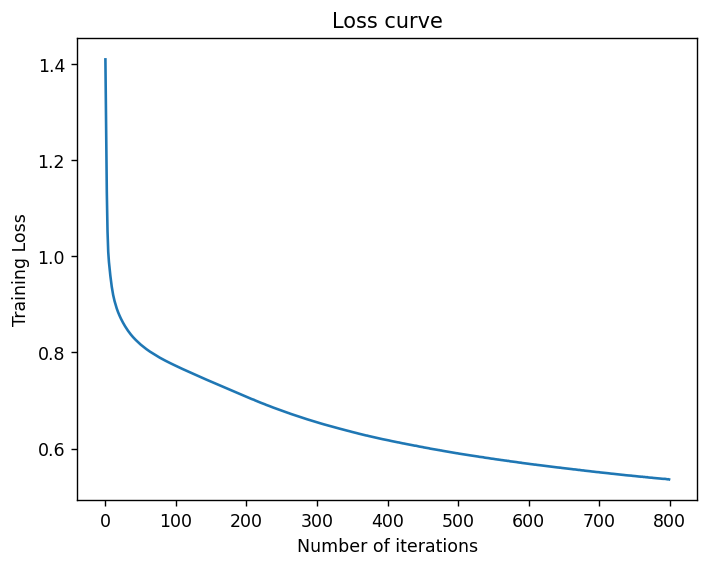

In [44]:
lossPerIteration = m5.loss_curve_ #model loss curve
plt.figure(dpi=125)
plt.plot(lossPerIteration)
plt.title("Loss curve")
plt.xlabel("Number of iterations")
plt.ylabel("Training Loss")
plt.show()

#### Confusion Matrix of best Model: Model 5

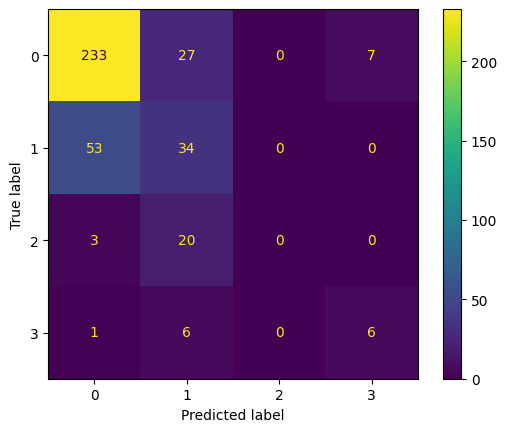

In [47]:
conf_mat = confusion_matrix(y_test, pred_m5)

cm_d = ConfusionMatrixDisplay(confusion_matrix = conf_mat)

cm_d.plot()
plt.show()

### Comparative Analysis: Evaluation Results

|Model|Cost|Loss|Accuracy|Senstivity|UAR|AUC|
|-|-|-|-|-|-|-|
|Model 1|234|0.768|0.684|0.250|0.171|0.627|
|Model 2|233|0.771|0.687|0.253|0.422|0.648|
|Model 3|234|0.764|0.685|0.250|0.171|0.644|
|Model 4|210|0.617|0.687|0.365|0.389|0.788|
|Model 5|**197**|0.536|0.700|0.431|0.414|0.853|
|Model 6|241|**0.412**|**0.762**|**0.696**|**0.635**|**0.932**|

- If we see a comparative analysis of the models, just on the basis of total cost of misclassification, we can say that Model 5 is the best. 
- But all other evaluation metrics suggest Model 6 to be the best. This may be primarily due to the fact that Model 6 misclassifies the higher quality cars, which have high cost of misclassification.